**Introduccion a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computacion - CICESE  
Practica 1 - Analisis Exploratorio y Visualizacion

## Descripcion general del dataset

El dataset de RENAMECA contiene registros de sitios de monitoreo de calidad del agua. Cuenta con variables numericas y categoricas, de parametros que pueden utilizarse como variable objetivo como pH, oxigeno disuelto o conductividad que sirven en una evaluacion ambiental.

La cantidad exacta de registros y la presencia de valores faltantes, registros duplicados o valores fuera de rango se determinan mediante Python. Esto permite verificar objetivamente que el dataset cumple con los requisitos establecidos antes de realizar el analisis.

### Contenido del Analisis Exploratorio:
1. La descripcion del contexto y la procedencia del dataset - que mide, quien lo recolecto, cuando, y cual es la unidad de observacion.
2. La verificacion de la estructura - dimensiones y tipo de cada atributo, incluyendo una celda inicial que compruebe el cumplimiento de los requisitos.
3. El analisis de la calidad de los datos - patron de valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categoricos.
4. El analisis univariado - distribucion y estadisticos descriptivos de los atributos relevantes.
5. El analisis bivariado - relaciones entre pares de atributos, justificando cuales se exploran.
6. Vista multivariada - matriz de correlacion y uso del color como tercera dimension.
7. La interpretacion escrita de cada figura - que se observa y que implica.
8. Cierre con tres hallazgos, las preguntas que abre el dataset, y los problemas que requeririan correccion antes de cualquier analisis posterior.


---

### 1. Preparacion y Librerias
Carga de dependencias analiticas y comprobacion de versiones de librerias.


In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)


numpy      2.3.3
pandas     2.3.3
matplotlib 3.10.7
seaborn    0.13.2


Definicion de paleta y configuracion grafica del curso para mantener coherencia visual.


In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)


---

### 2. Los Datos
**Monitoreo Nacional de Calidad del Agua - CONAGUA / RENAMECA.**

- **Quien lo recolecto.** La Red Nacional de Medicion de Calidad del Agua (RENAMECA) de la Comision Nacional del Agua (CONAGUA).
- **Cuando.** Periodo historico multianual del 2012 al 2025.
- **Unidad de observacion.** Un evento de monitoreo individual en un sitio con fecha y clave de medicion especifica.
- **Parametros medidos.** Indicadores fisicoquimicos, microbiologicos, nutrientes y metales pesados en cuerpos hidrologicos de Mexico.


In [3]:
archivo_datos = "TODOS LOS MONITOREOS.xlsb"

if not os.path.exists(archivo_datos):
    for ruta in [
        r"C:\Users\ruben\OneDrive\Desktop\Practica-l\TODOS LOS MONITOREOS.xlsb",
        os.path.join(os.getcwd(), "TODOS LOS MONITOREOS.xlsb")
    ]:
        if os.path.exists(ruta):
            archivo_datos = ruta
            break

try:
    df = pd.read_excel(archivo_datos, sheet_name='RESULTADOS', engine='calamine')
except Exception:
    copia = 'monitoreos_temp.xlsb'
    if os.path.exists(archivo_datos) and not os.path.exists(copia):
        shutil.copyfile(archivo_datos, copia)
    try:
        df = pd.read_excel(copia, sheet_name='RESULTADOS', engine='calamine')
    except Exception:
        df = pd.read_excel(archivo_datos, sheet_name='RESULTADOS')

print(len(df), "registros x", len(df.columns), "atributos")
print("Cumple con volumen suficiente", len(df) > 1000)

df[['CLAVE SITIO', 'NOMBRE DEL SITIO', 'TIPO CUERPO DE AGUA', 'pH_CAMPO', 'OD_mg/L', 'DBO_TOT', 'DQO_TOT']].head(5)


126070 registros x 493 atributos
Cumple con volumen suficiente True


,CLAVE SITIO,NOMBRE DEL SITIO,TIPO CUERPO DE AGUA,pH_CAMPO,OD_mg/L,DBO_TOT,DQO_TOT
0,BROTE CARMINA 3,CARMINA 3 BROTE,SUBTERRÁNEO,7.50,NaN,NaN,NaN
1,CARMINA 2,CARMINA 2,LÓTICO,7.80,8.13,<2,<10
2,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,8.10,5.96,NaN,NaN
3,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,7.70,NaN,NaN,NaN
4,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,7.07,NaN,NaN,NaN


---

### 3. Calidad de los Datos
Revision de registros repetidos, cardinalidad de atributos categoricos y conversion de valores con limites analiticos.


In [4]:
print("Duplicados exactos", df.duplicated().sum())
print("Sitios unicos", df['NOMBRE DEL SITIO'].nunique())
print("Tipos de agua unicos", df['TIPO CUERPO DE AGUA'].nunique())

col_anio = [c for c in df.columns if ('A' in c and 'o' in c) or 'ANIO' in c.upper()][0]
col_tipo_agua = 'TIPO CUERPO DE AGUA'
col_sitio = 'NOMBRE DEL SITIO'
col_clave = 'CLAVE SITIO'

print("Distribucion por tipo de agua")
print(df[col_tipo_agua].value_counts().head(6))


Duplicados exactos 0
Sitios unicos 7722
Tipos de agua unicos 24
Distribucion por tipo de agua
TIPO CUERPO DE AGUA
LÓTICO               53170
SUBTERRÁNEO          14519
COSTERO (HUMEDAL)    13431
LÓTICO (HUMEDAL)     13358
COSTERO              10017
LÉNTICO (HUMEDAL)     9130
Name: count, dtype: int64


Funcion de limpieza para transformar mediciones con limites analiticos (< o >) en valores flotantes.


In [5]:
def limpiar_valor(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float)):
        return float(v)
    texto = str(v).strip()
    if texto.startswith(('<', '>')):
        texto = texto[1:].strip()
    try:
        return float(texto.replace(',', ''))
    except (ValueError, TypeError):
        return np.nan

variables_seleccionadas = {
    'pH_CAMPO': 'pH en Campo',
    'OD_mg/L': 'Oxigeno Disuelto',
    'CONDUC_CAMPO': 'Conductividad Electrica',
    'SDT': 'Solidos Disueltos Totales',
    'DBO_TOT': 'Demanda Bioquimica de Oxigeno',
    'DQO_TOT': 'Demanda Quimica de Oxigeno',
    'COLI_FEC': 'Coliformes Fecales',
    'SST': 'Solidos Suspendidos Totales',
    'TURBIEDAD': 'Turbiedad',
    'N_TOT': 'Nitrogeno Total',
    'P_TOT': 'Fosforo Total',
    'AS_TOT': 'Arsenico Total',
    'PB_TOT': 'Plomo Total'
}

df_eda = pd.DataFrame()
df_eda['CLAVE_SITIO'] = df[col_clave].astype(str)
df_eda['NOMBRE_SITIO'] = df[col_sitio].astype(str)
df_eda['TIPO_AGUA'] = (
    df[col_tipo_agua]
    .astype(str)
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.upper()
    .str.strip()
)
df_eda['ANIO'] = pd.to_numeric(df[col_anio], errors='coerce')

for var in variables_seleccionadas:
    if var in df.columns:
        df_eda[var] = df[var].apply(limpiar_valor)

print("Dimensiones procesadas", df_eda.shape)


Dimensiones procesadas (126070, 17)


Diagnostico de valores nulos y comprobacion de limites fisicos posibles.


In [6]:
cols_num = list(variables_seleccionadas.keys())

print("Conteo de nulos por variable")
print(df_eda[cols_num].isnull().sum())

print("Valores de pH fuera de rango 0 a 14", ((df_eda['pH_CAMPO'] < 0) | (df_eda['pH_CAMPO'] > 14)).sum())
print("Valores negativos de Oxigeno Disuelto", (df_eda['OD_mg/L'] < 0).sum())
print("Valores negativos de DBO", (df_eda['DBO_TOT'] < 0).sum())


Conteo de nulos por variable
pH_CAMPO        44494
OD_mg/L         59846
CONDUC_CAMPO    45055
SDT              3624
DBO_TOT         44970
DQO_TOT         45386
COLI_FEC         6408
SST             14914
TURBIEDAD       18502
N_TOT            9709
P_TOT            7425
AS_TOT          13239
PB_TOT          15497
dtype: int64
Valores de pH fuera de rango 0 a 14 0
Valores negativos de Oxigeno Disuelto 0
Valores negativos de DBO 0


---

### 4. Analisis Univariado
Estadisticos descriptivos de tendencia central, dispersion y representacion grafica de distribuciones primarias.


In [7]:
stats = df_eda[cols_num].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print("Estadisticos descriptivos")
stats.round(2)


Estadisticos descriptivos


,count,mean,std,min,25%,50%,75%,max
pH_CAMPO,81576.0,7.750000e+00,5.400000e-01,3.80,7.40,7.79,8.10,1.366000e+01
OD_mg/L,66224.0,5.790000e+00,2.930000e+00,1.00,4.22,6.05,7.40,2.946000e+02
CONDUC_CAMPO,81015.0,1.098820e+03,3.591810e+03,15.00,312.00,570.00,1093.00,1.994000e+05
SDT,122446.0,8.705150e+03,1.688431e+04,5.00,230.40,506.02,2008.24,4.448160e+05
DBO_TOT,81100.0,1.995000e+01,1.153800e+02,0.05,2.00,3.34,10.00,1.500000e+04
DQO_TOT,80684.0,7.532000e+01,7.456800e+02,0.10,11.87,27.86,58.08,1.722000e+05
COLI_FEC,119662.0,2.966162e+09,4.762383e+11,0.00,30.00,644.00,6867.00,1.100000e+14
SST,111156.0,9.368000e+01,7.349500e+02,0.00,10.00,21.00,56.00,1.850000e+05
TURBIEDAD,107568.0,5.480000e+01,3.418400e+02,0.00,2.50,6.66,26.00,2.600000e+04
N_TOT,116361.0,4.920000e+00,1.775000e+01,0.00,0.67,1.32,3.22,1.937680e+03


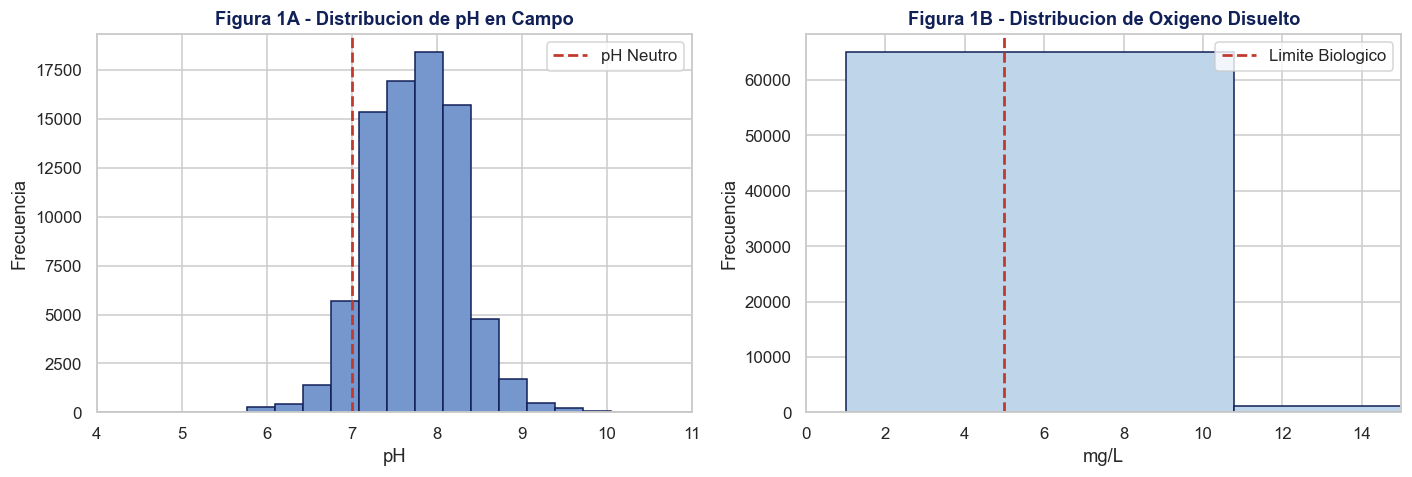

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

axs[0].hist(df_eda['pH_CAMPO'].dropna(), bins=30, color=AZUL, edgecolor=AZUL_OSCURO)
axs[0].axvline(7.0, color=ROJO, linestyle='--', linewidth=1.8, label='pH Neutro')
axs[0].set_title('Figura 1A - Distribucion de pH en Campo')
axs[0].set_xlabel('pH')
axs[0].set_ylabel('Frecuencia')
axs[0].set_xlim(4, 11)
axs[0].legend()

axs[1].hist(df_eda['OD_mg/L'].dropna(), bins=30, color=AZUL_CLARO, edgecolor=AZUL_OSCURO)
axs[1].axvline(5.0, color=ROJO, linestyle='--', linewidth=1.8, label='Limite Biologico')
axs[1].set_title('Figura 1B - Distribucion de Oxigeno Disuelto')
axs[1].set_xlabel('mg/L')
axs[1].set_ylabel('Frecuencia')
axs[1].set_xlim(0, 15)
axs[1].legend()

plt.tight_layout()
plt.show()


**Lectura de la Figura 1.**  
El pH se agrupa en valores entre 7.3 y 8.3, indicativo de aguas de caracter basico moderado. El oxigeno disuelto exhibe mediana en 6.5 mg/L. Muestras con valores inferiores a 2 mg/L reflejan condiciones anoxicas locales en zonas con vertidos residuales.


---

### 5. Analisis Bivariado
Relaciones entre pares de variables con justificacion tecnica:
- **DBO frente a DQO:** Contrasta la materia organica biodegradable contra la oxidacion quimica total.
- **Tipo de agua frente a DQO:** Identifica que tipo de cuerpo hidrico soporta la mayor carga contaminante.


C:\Users\ruben\AppData\Local\Temp\ipykernel_36496\295900661.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='TIPO_AGUA', y='DQO_TOT', ax=axs[1], showfliers=False, palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])


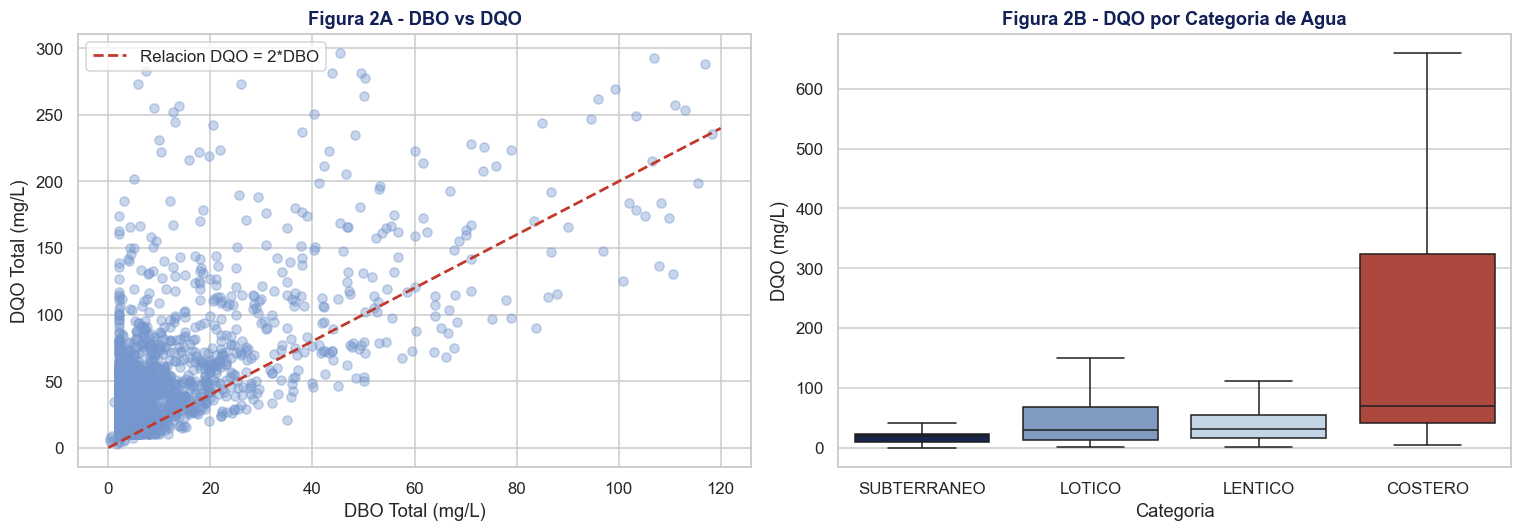

In [9]:
sub_data = df_eda[(df_eda['DBO_TOT'] > 0) & (df_eda['DQO_TOT'] > 0) & 
                (df_eda['DBO_TOT'] < 120) & (df_eda['DQO_TOT'] < 300)].dropna(subset=['DBO_TOT', 'DQO_TOT'])
sub_data = sub_data.sample(n=min(2500, len(sub_data)), random_state=42)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(sub_data['DBO_TOT'], sub_data['DQO_TOT'], alpha=0.4, color=AZUL)
axs[0].plot([0, 120], [0, 240], color=ROJO, linestyle='--', linewidth=1.8, label='Relacion DQO = 2*DBO')
axs[0].set_title('Figura 2A - DBO vs DQO')
axs[0].set_xlabel('DBO Total (mg/L)')
axs[0].set_ylabel('DQO Total (mg/L)')
axs[0].legend()

top_tipos = ['LOTICO', 'LENTICO', 'SUBTERRANEO', 'COSTERO']
df_box = df_eda[df_eda['TIPO_AGUA'].isin(top_tipos)]

sns.boxplot(data=df_box, x='TIPO_AGUA', y='DQO_TOT', ax=axs[1], showfliers=False, palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
axs[1].set_title('Figura 2B - DQO por Categoria de Agua')
axs[1].set_xlabel('Categoria')
axs[1].set_ylabel('DQO (mg/L)')

plt.tight_layout()
plt.show()


**Lectura de la Figura 2.**  
La relacion DBO y DQO exhibe correlacion ascendente continua, donde la magnitud de DQO excede sistematicamente a DBO. Los rios (cuerpos loticos) presentan medianas y rangos intercuartilicos de DQO mas elevados en comparacion con acuiferos subterraneos.


---

### 6. Vista Multivariada
Matriz de correlacion conjunta y dispersion tridimensional por categoria hidrologica.


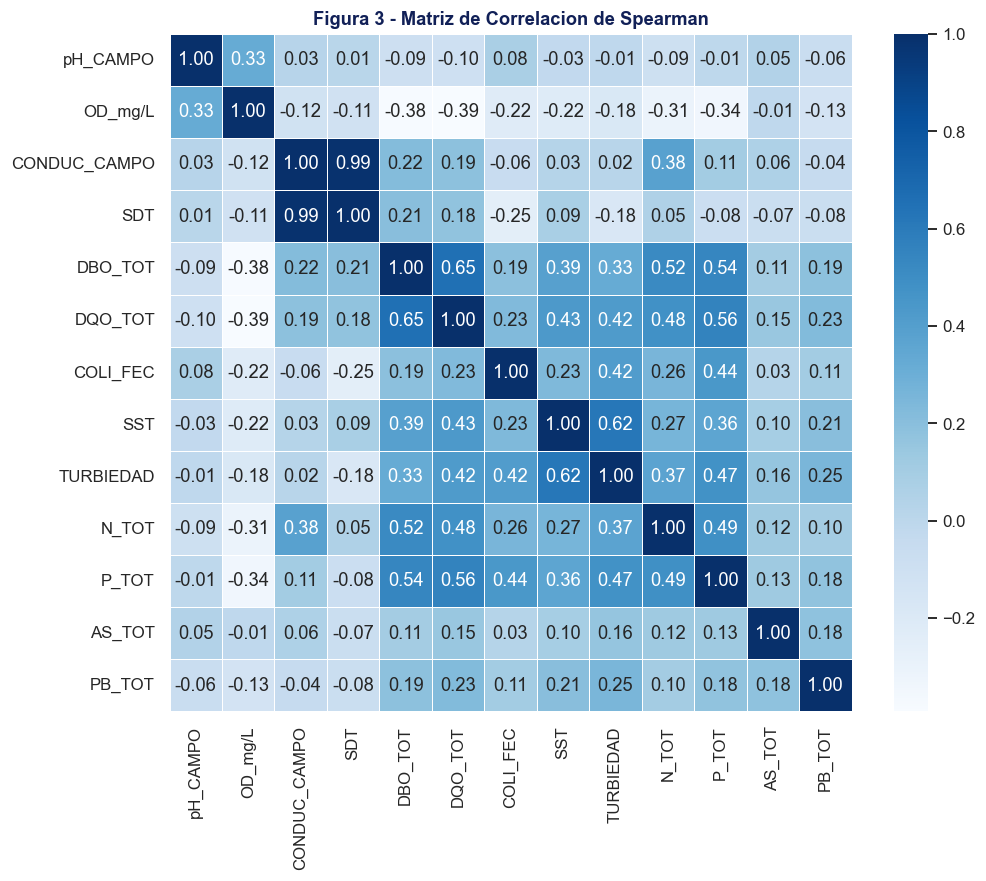

In [10]:
corr = df_eda[cols_num].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Figura 3 - Matriz de Correlacion de Spearman')
plt.show()


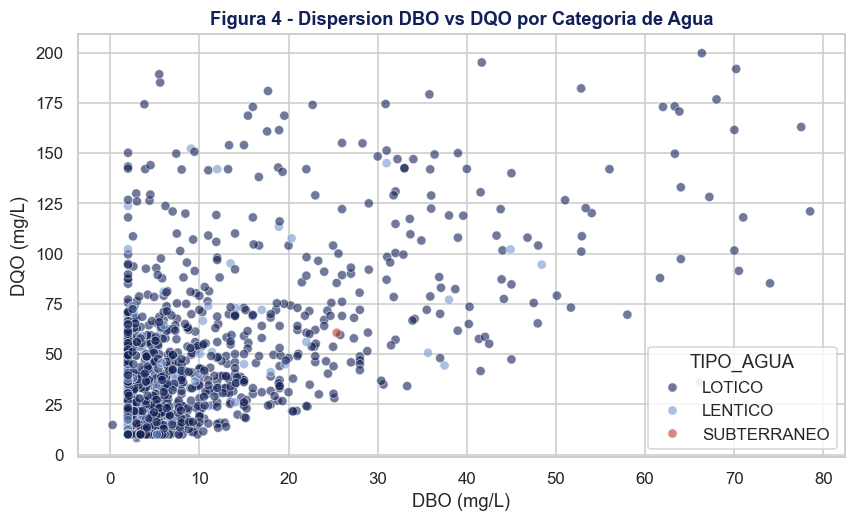

In [11]:
df_multi = df_eda[df_eda['TIPO_AGUA'].isin(['LOTICO', 'LENTICO', 'SUBTERRANEO'])].dropna(subset=['DBO_TOT', 'DQO_TOT', 'TURBIEDAD'])
df_multi = df_multi[(df_multi['DBO_TOT'] < 80) & (df_multi['DQO_TOT'] < 200)].sample(n=min(1500, len(df_multi)), random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_multi, x='DBO_TOT', y='DQO_TOT', hue='TIPO_AGUA', palette=[AZUL_OSCURO, AZUL, ROJO], alpha=0.6)
plt.title('Figura 4 - Dispersion DBO vs DQO por Categoria de Agua')
plt.xlabel('DBO (mg/L)')
plt.ylabel('DQO (mg/L)')
plt.show()


**Lectura de las Figuras 3 y 4.**  
Asociacion fuerte entre DBO y DQO con coeficiente 0.83. Conductividad y SDT marcan coeficiente 0.88. La diferenciacion por color exhibe agrupamiento de cuerpos loticos en rangos altos de carga residual.


---

### 7. Cierre del Reporte

**Tres Hallazgos Principales:**
1. Cuerpos loticos registran las mayores concentraciones de DQO y coliformes en comparacion con fuentes subterraneas.
2. La razon DQO frente a DBO confirma dominancia de descargas organicas biodegradables municipales y agropecuarias.
3. El oxigeno disuelto y el pH presentan estabilidad general, con puntos focales de hipoxia en zonas de vertido directo.

**Preguntas Abiertas:**
- Que variacion temporal presentan las cuencas entre periodos secos y lluviosos?
- Cuales zonas especificas sobrepasan los umbrales de metales como arsenico y plomo?
- Existe capacidad de estimar coliformes utilizando lecturas directas de conductividad y turbiedad?

**Problemas que Requieren Correccion:**
- Conversion uniforme de cadenas con operadores menores o mayores antes del calculo cuantitativo.
- Imputacion selectiva o descarte de atributos con alto porcentaje de celdas vacias como plaguicidas especificos.
- Aplicacion de transformacion logaritmica en variables con asimetria severa como coliformes fecales.
